In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

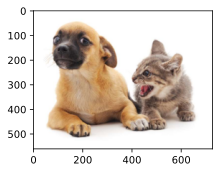

In [3]:
import os

# Create img folder if it doesn't exist
os.makedirs('../img/', exist_ok=True)

# Download from d2l repository
d2l.DATA_HUB['catdog'] = (d2l.DATA_URL + 'catdog.jpg', 
                           'c7e470db3935713eaa633f792172ea37')

# Use it
fname = d2l.download('catdog')
d2l.set_figsize()
img = d2l.plt.imread(fname)
d2l.plt.imshow(img)
d2l.plt.show()

In [4]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

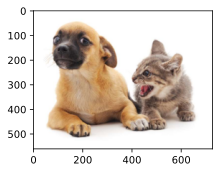

In [10]:
import os
import torch
import torchvision
import d2l.torch as d2l
from PIL import Image

# Create img folder if it doesn't exist
os.makedirs('../img/', exist_ok=True)

# Download from d2l repository
d2l.DATA_HUB['catdog'] = (d2l.DATA_URL + 'catdog.jpg', 
                           'c7e470db3935713eaa633f792172ea37')

# Download and get filename
fname = d2l.download('catdog')

# Convert to PIL Image (torchvision transforms need PIL Image)
img = Image.open(fname)

# Display original
d2l.set_figsize()
d2l.plt.imshow(img)
d2l.plt.show()

In [8]:
# Define apply function
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)



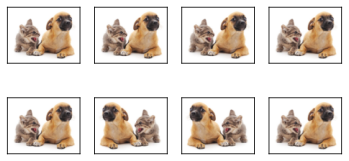

In [9]:
# Apply horizontal flip augmentation
apply(img, torchvision.transforms.RandomHorizontalFlip())

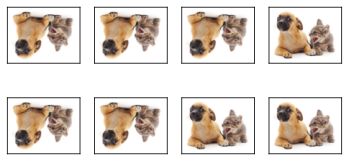

In [11]:
apply(img, torchvision.transforms.RandomVerticalFlip())

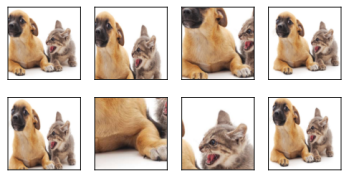

In [12]:
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

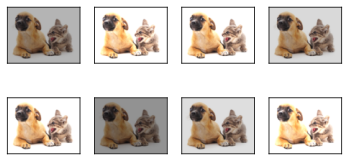

In [13]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

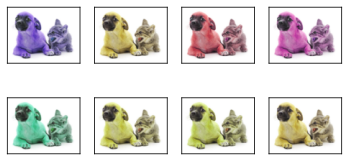

In [14]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

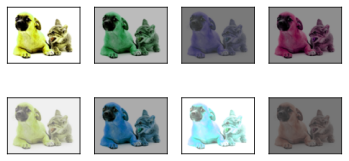

In [15]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

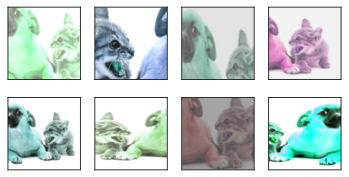

In [16]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

In [ ]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data",
                                          download=True)
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8);

27.9%